dataset:
   X  Y  Z Class
0  1  1  1     I
1  1  1  0     I
2  0  0  1    II
3  1  0  0    II

Information Gain:
X = 0.0
Y = 1.0
Z = 0.0

Actual Classes:
['I', 'I', 'II', 'II']

Predicted Classes:
['I', 'I', 'II', 'II']


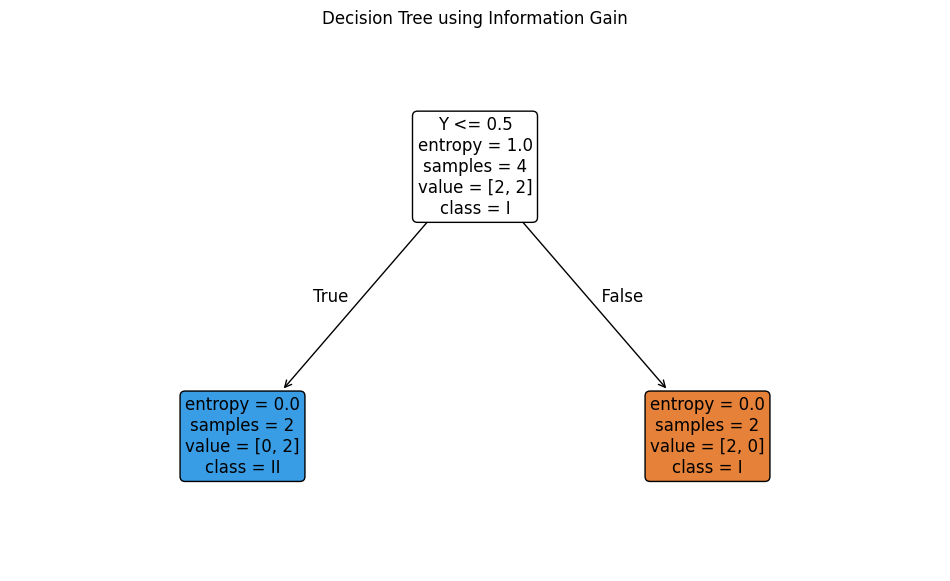

In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
data={
    'X':[1,1,0,1],
    'Y':[1,1,0,0],
    'Z':[1,0,1,0],
    'Class':['I','I','II','II']
}
df=pd.DataFrame(data)
print('dataset:')
print(df)
X=df[['X','Y','Z']]
y=df['Class']
model=DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
model.fit(X,y)
print('\nInformation Gain:')
for feature,importance in zip(X.columns,model.feature_importances_):
    print(feature,'=',round(importance,4))
y_pred=model.predict(X)
print("\nActual Classes:")
print(list(y))
print("\nPredicted Classes:")
print(list(y_pred))
plt.figure(figsize=(12,7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree using Information Gain")
plt.show()

IRIS DATASET

Dataset Shape:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Training Samples: 120
Testing Samples: 30

Decision Tree Training Completed!

Actual Classes:
['Iris-setosa', 'Iris-virginica', 'Iris-versicolor', 'Iris-versico

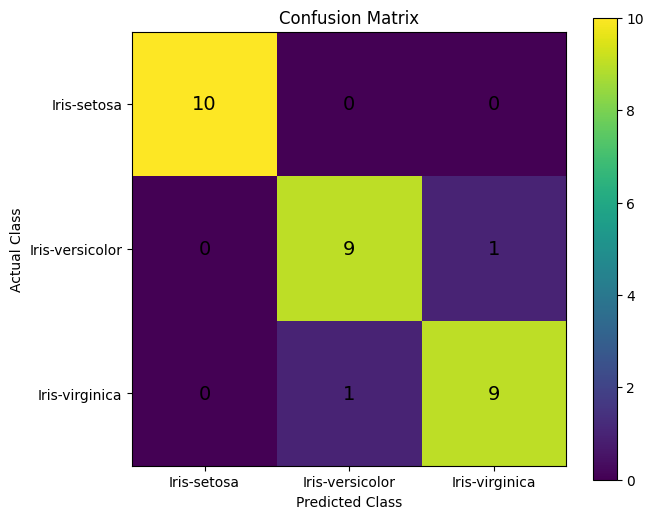


Feature Importance
SepalLengthCm = 0.0066
SepalWidthCm = 0.0146
PetalLengthCm = 0.672
PetalWidthCm = 0.3068


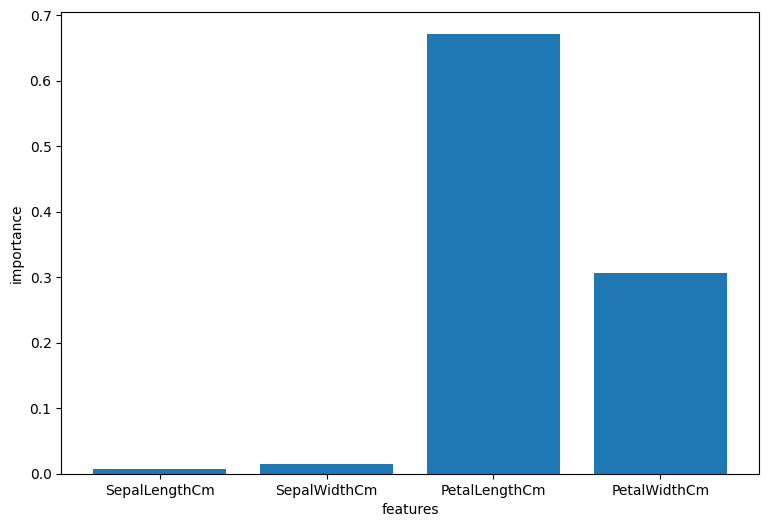

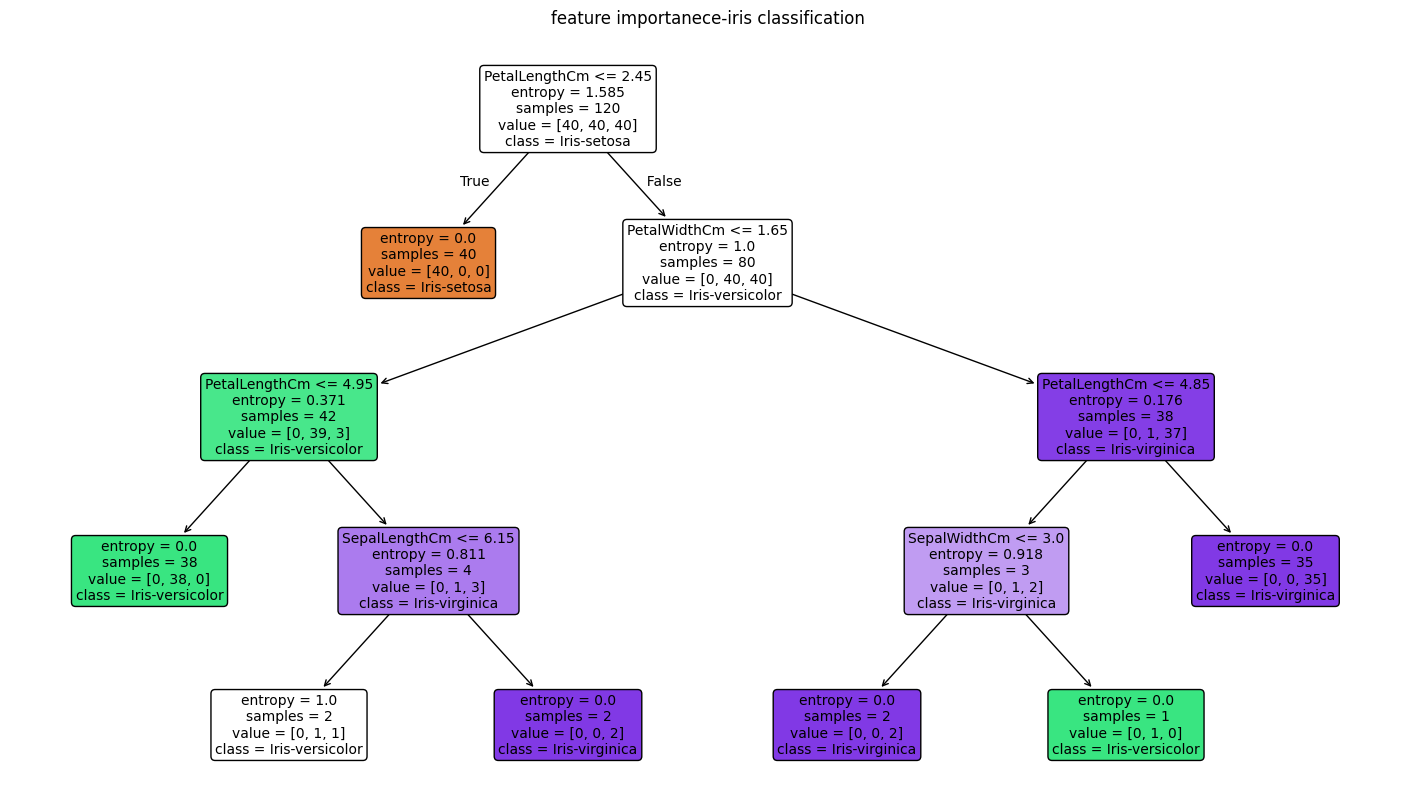

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

path = "/kaggle/input/datasets/uciml/iris/Iris.csv"
df = pd.read_csv(path)

print("=" * 60)
print("IRIS DATASET")
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Information:")
print(df.info())
print("\nClass Distribution:")
print(df["Species"].value_counts())

X = df[
    ["SepalLengthCm",
     "SepalWidthCm",
     "PetalLengthCm",
     "PetalWidthCm"
     ]
]
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

print("\nDecision Tree Training Completed!")

y_pred = model.predict(X_test)

print("\nActual Classes:")
print(list(y_test))
print("\nPredicted Classes:")
print(list(y_pred))

print("\n" + "=" * 60)
print("Model Accuracy")
print("=" * 60)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy=", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(
    [0, 1, 2],
    model.classes_
)
plt.yticks(
    [0, 1, 2],
    model.classes_
)
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )
plt.colorbar()
plt.show()

print("\n" + "=" * 60)
print("Feature Importance")
print("=" * 60)
for feature, importance in zip(
    X.columns,
    model.feature_importances_
):
    print(feature, "=", round(importance, 4))

plt.figure(figsize=(9, 6))
plt.bar(
    X.columns,
    model.feature_importances_   # fixed: was model.feature_importance_
)
plt.xlabel('features')
plt.ylabel("importance")
plt.show()

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("feature importanece-iris classification")
plt.show()